In [1]:
import cv2
import numpy as np
import os
import pandas as pd

## Action Units:
1 Inner Brow Raiser 
2 Outer Brow Raiser 
4 Brow Lowerer 
5 Upper Lid Raiser 
6 Cheek Raiser 
9 Nose Wrinkler 
12 Lip Corner Puller 
15 Lip Corner Depressor 
17 Chin Raiser 
20 Lip Stretcher 
25 Lips Part
26 Jaw Drop

NOT to use: SN005 and SN009 subjects for display

In [2]:
# All 27 subjects
subject_list = ['SN001', 'SN002', 'SN003', 'SN004', 'SN005', 'SN006', 'SN007', 'SN008', 'SN009', 'SN010', 
                'SN011', 'SN012', 'SN013', 'SN016', 'SN017', 'SN018', 'SN021', 'SN023', 'SN024', 'SN025', 
                'SN026', 'SN027', 'SN028', 'SN029', 'SN030', 'SN031', 'SN032']
# Action units 
AU_list = ['au1', 'au2', 'au4', 'au5', 'au6', 'au9', 'au12', 'au15', 'au17', 'au20', 'au25', 'au26']

## Convert right camera videos to array and display a sample subject

In [13]:
s = 5
video_path = 'Video_RightCamera/RightVideo{}_comp.avi'.format(subject_list[s])
cap = cv2.VideoCapture(video_path)

frames = []
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    frame = cv2.resize(frame, (256, 256))           # Resize to 256x256
    frames.append(frame)

cap.release()
video_array = np.array(frames)
print("Video shape:", video_array.shape)  # (num_frames, height, width, 3)

Video shape: (4845, 256, 256, 3)


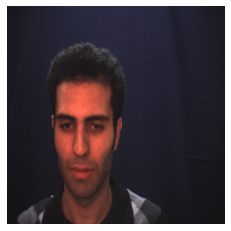

In [4]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Assume video_array contains RGB frames: shape (N, H, W, 3)
frames = video_array[::len(video_array)]  # Sample 100 frames for faster rendering

# Create figure and axis
fig, ax = plt.subplots()
im = ax.imshow(frames[0])
ax.axis('off')

# Animation update function
def update(i):
    im.set_array(frames[i])
    return [im]

# Create animation
ani = animation.FuncAnimation(
    fig, update, frames=len(frames), interval=100, blit=True, repeat=True
)

# Display in notebook
HTML(ani.to_jshtml())

## Generate and save label array data of shape (4844, 12) for each subject
Because some of the frames > 4844 is missing

In [5]:
N_frames = 4844

label_root = 'ActionUnit_Labels'
subject_au_dict = {}

for subject in subject_list:
   subject_folder = os.path.join(label_root, subject)
   
   au_columns = []
   for au in AU_list:
       au_file = os.path.join(subject_folder, f"{subject}_{au}.txt")
       df = pd.read_csv(au_file, sep=',', header=None, names=['frame', au])
       au_columns.append(df[au].values)

   au_array = np.stack(au_columns, axis=1).astype(np.float32)  # shape: (4845, 12)
   subject_au_dict[subject] = au_array[:N_frames]


In [7]:
save_dir = 'data_arrays_npy/labels'
os.makedirs(save_dir, exist_ok=True)

for subject, arr in subject_au_dict.items():
   np.save(os.path.join(save_dir, f"{subject}_au_labels.npy"), arr)

## Generate and save video array of shape (4844, H, W, 3) for each subject 

In [8]:
video_root = 'Video_RightCamera'
video_dict = {}  # Stores video frames for each subject

for subject in subject_list:
   video_path = f"{video_root}/RightVideo{subject}_comp.avi"
   cap = cv2.VideoCapture(video_path)

   frames = []
   while cap.isOpened():
       ret, frame = cap.read()
       if not ret:
           break
       frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
       frame = cv2.resize(frame, (256, 256))  
       frames.append(frame)

   cap.release()
   
   video_array = np.array(frames[:N_frames])  # shape: (num_frames, H, W, 3)
   video_dict[subject] = video_array
   print(f"{subject} video shape:", video_array.shape)

In [9]:
save_dir = 'data_arrays_npy/video_array'
os.makedirs(save_dir, exist_ok=True)

for subject, video_array in video_dict.items():
    save_path = os.path.join(save_dir, f"{subject}_video_array.npy")
    np.save(save_path, video_array)
    print(f"Saved {subject} video to {save_path}")

## Subject specific Action Units (AUs):
### Compute AU Statistics per Subject
To analyze Action Unit (AU) dynamics, we first compute summary statistics for each subject in the DISFA dataset. 

For each subject, we load the AU label array and calculate:

Mean intensity: Average activation level for each AU across frames.

Activation count: Number of frames where each AU is active (i.e., AU intensity > 0).

In [10]:
# Store AU stats per subject
au_stats_per_subject = {}

for subject in subject_list:
    au_labels = np.load(f'data_arrays_npy/labels/{subject}_au_labels.npy')  # (N_frames, 12)
    
    mean_intensity = np.mean(au_labels, axis=0)
    activation_count = np.sum(au_labels > 0, axis=0)
    
    au_stats_per_subject[subject] = {
        'mean_intensity': mean_intensity,
        'activation_count': activation_count
    }

# Create a DataFrame where each row corresponds to a subject and each column to an AU, 
# representing the number of active frames for that AU:    
# Create summary DataFrame: rows=subjects, cols=AU activation counts
activation_df = pd.DataFrame({
    subject: au_stats_per_subject[subject]['activation_count']
    for subject in subject_list
}, index=AU_list).T  # subjects as rows, AUs as columns

# Optional: visualize activation counts
display(activation_df)
#print(activation_df.to_string())

,au1,au2,au4,au5,au6,au9,au12,au15,au17,au20,au25,au26
SN001,8,0,40,0,0,0,692,36,36,28,932,321
SN002,228,307,23,34,229,143,1237,200,114,26,1848,1891
SN003,715,27,2738,42,1830,1554,781,151,870,260,1855,1571
SN004,1318,1604,2012,71,1817,495,1714,246,1183,297,1439,558
SN005,37,9,288,35,167,0,739,231,140,705,1184,864
SN006,0,0,588,0,2302,189,1788,60,281,50,1698,388
SN007,117,196,124,97,958,344,1071,9,411,444,959,369
SN008,251,260,880,24,708,417,508,21,132,11,522,209
SN009,28,78,29,0,15,0,974,17,259,158,358,147
SN010,43,80,412,723,772,0,1237,0,16,45,856,763


## Convert left camera videos to array

In [4]:
N_frames = 4844

video_root = 'Video_LeftCamera'
video_dict = {}  # Stores video frames for each subject

for subject in subject_list:
    video_path = f"{video_root}/LeftVideo{subject}_comp.avi"
    cap = cv2.VideoCapture(video_path)

    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (256, 256))  
        frames.append(frame)

    cap.release()
    
    video_array = np.array(frames[:N_frames])  # shape: (num_frames, H, W, 3)
    video_dict[subject] = video_array
    print(f"{subject} video shape:", video_array.shape)

save_dir = 'data_arrays_npy/LeftVideo_array'
os.makedirs(save_dir, exist_ok=True)

for subject, video_array in video_dict.items():
    save_path = os.path.join(save_dir, f"{subject}_LeftVideo_array.npy")
    np.save(save_path, video_array)
    print(f"Saved {subject} video to {save_path}")

SN001 video shape: (4844, 256, 256, 3)
SN002 video shape: (4844, 256, 256, 3)
SN003 video shape: (4844, 256, 256, 3)
SN004 video shape: (4844, 256, 256, 3)
SN005 video shape: (4844, 256, 256, 3)
SN006 video shape: (4844, 256, 256, 3)
SN007 video shape: (4844, 256, 256, 3)
SN008 video shape: (4844, 256, 256, 3)
SN009 video shape: (4844, 256, 256, 3)
SN010 video shape: (4844, 256, 256, 3)
SN011 video shape: (4844, 256, 256, 3)
SN012 video shape: (4844, 256, 256, 3)
SN013 video shape: (4844, 256, 256, 3)
SN016 video shape: (4844, 256, 256, 3)
SN017 video shape: (4844, 256, 256, 3)
SN018 video shape: (4844, 256, 256, 3)
SN021 video shape: (4844, 256, 256, 3)
SN023 video shape: (4844, 256, 256, 3)
SN024 video shape: (4844, 256, 256, 3)
SN025 video shape: (4844, 256, 256, 3)
SN026 video shape: (4844, 256, 256, 3)
SN027 video shape: (4844, 256, 256, 3)
SN028 video shape: (4844, 256, 256, 3)
SN029 video shape: (4844, 256, 256, 3)
SN030 video shape: (4844, 256, 256, 3)
SN031 video shape: (4844,